# DOHMH New York City Restaurant Inspection Results

In this file, we analyze the behavior and performance of the self-balancing sampler on the NYC [Restaurant Inspection Dataset](https://data.cityofnewyork.us/Health/DOHMH-New-York-City-Restaurant-Inspection-Results/43nn-pn8j/about_data) which is available through [NYC Open Data](https://opendata.cityofnewyork.us/).


##### Ideas

To choose a certain bias parameter $\beta$ for our sampler, maybe we could somehow train a model to predict the likelihood of a restaurant to fail a health inspection, and bias our sampler towards the high-risk restaurants. In this case, we may want to keep some of the extraneous features (like Borough, restaurant name, and whatnot) in order to use them as predictive features (e.g. maybe certain restaurants are more prone to health issues due to the kinds of ingredients they tend to use, which require more careful care.)

The health inspectors already have some sort of a biasing towards reinspecting establishments receiving poor scores:

>If the initial score is less than 14 points, the next initial inspection occurs approximately 12 months later; if the higher of the scores is 14-27 points, the next initial  will be 5 to 7 months after re-inspection; if the higher score is 28 or more points, the next initial inspection will occur 3 to 5 months after re-inspection.

Performance analysis:
* Detection delay: how long do we tend to wait before detecting a health concern. 

In [142]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style='whitegrid', context='notebook')

import os
from pathlib import Path

workdir = Path(os.getcwd())
data_dir = workdir / 'data'

In [143]:
from IPython.display import display, HTML

def side_by_side_tables(tables, titles=None):
    if titles is None:
        titles = [""] * len(tables)

    html_parts = []
    for title, table in zip(titles, tables):
        html = table.to_html()
        html_parts.append(f"""
        <div style="display: inline-block; vertical-align: top; margin-right: 30px;">
            <h4 style="margin-bottom: 8px;">{title}</h4>
            {html}
        </div>
        """)

    display(HTML(f"""
    <div style="display: flex; gap: 30px; align-items: flex-start;">
        {''.join(html_parts)}
    </div>
    """))

## Data Schema

The *data/RestaurantInspectionDataDictionary_09242018.xlsx* file gives terse descriptions of the columns in this dataset while the *data/About_NYC_Restaurant_Inspection_Data_on_NYC_OpenData_050222.docx* file gives a broader exposition about what the data set contains. These encapsulate features like the location of the restauarant, contact information, the inspection date, inspection scores, and whatnot. There are a few features we are crucially interested in:

* **CAMIS**: A unique identifier for a specific restaurant.
* **Inspection Date**: Date inspection occurred.
* **Inspection Type**: Inspections are scheduled for various reasons: a pre-permit phase before a restaurant first opens, a periodic inspection, or a scheduled reinspection due to infractions. This field encodes that information. 
* **Score** and **Grade**: A numerical score in $[0, \infty)$ and its corresponding letter grade. Points are awarded for infractions, so low scores are better. Letter grades are assigned from these scores typically as follows $[0, 13] \mapsto A$, $[14, 27] \mapsto B$, and $[28, \infty) \mapsto C$. 


One crucial omission from the dataset: restaurants that go out of business are **removed from the dataset**. We must be a bit careful to handle this sort of surviorship bias. Moreover, when an inspection results in more than one violation, values for associated fields are **repeated for each additional violation record**. Again, we must carefully handle this duplicated data. 

In [ ]:
data_path = data_dir / 'raw' /'DOHMH_New_York_City_Restaurant_Inspection_Results_20260512.csv'
full_df = pd.read_csv(data_path)

In [11]:
display(list(full_df.columns))

['CAMIS',
 'DBA',
 'BORO',
 'BUILDING',
 'STREET',
 'ZIPCODE',
 'PHONE',
 'CUISINE DESCRIPTION',
 'INSPECTION DATE',
 'ACTION',
 'VIOLATION CODE',
 'VIOLATION DESCRIPTION',
 'CRITICAL FLAG',
 'SCORE',
 'GRADE',
 'GRADE DATE',
 'RECORD DATE',
 'INSPECTION TYPE',
 'Latitude',
 'Longitude',
 'Community Board',
 'Council District',
 'Census Tract',
 'BIN',
 'BBL',
 'NTA',
 'Location']

### Data Filtering, Cleaning, and Imputation

We start by performing some simple data-cleaning and filtering operatings.
* Filter to relevant columns of the dataset. 
* Convert date field to a pandas datetime object.
* Drop rows with missing numerical score AND missing letter grade, or with incomplete letter grade "N". Fill missing grades according to the given map from scores to grades. 
* Split inspection type into a program field (pre-permit, cyclic, etc) and the visit type (initial inspection, reinspection, etc).
* Drop rare inspection program (Interagency task force, accelerated inspection etc) and reduce to two common fields (pre-permit and cycle). The former occurs on initial opening of the establishment, and the latter on a cyclic basis. 
* Drop rare inspection types and restrict to two most common: initial inspections and re-inspections.
* Drop duplicate rows that occur when a single inspection induces several violations. We do so by dropping duplicate (id, date) pairs.
* Sort the rows by date.


Maybe we should also possible:
*  **Drop re-inspections** (maybe???), They mention in the About document that:

> The program allows for a two-step inspection process, providing an opportunity for restaurants who do not receive an “A” on their initial inspection to be re-inspected.  This re-inspection occurs no less than 7 days after the initial inspection. 

It is plausible these re-inspections occur much sooner than the typical inter-inspection waiting time. 


In [123]:
# filter dataset to include only relevent columns
columns_to_keep = ['CAMIS', 'INSPECTION DATE', 'GRADE', 'SCORE', 'INSPECTION TYPE']
rename_map = {'CAMIS':'id', 'INSPECTION DATE':'date', 'GRADE':'grade', 'SCORE':'score', 'INSPECTION TYPE':'type'}
df = full_df[columns_to_keep].copy()
df.rename(columns=rename_map, inplace=True)

# drop missing rows
mask = df['grade'].isna() & df['score'].isna()
df_filtered = df[~mask]

# fill missing grades using scores
def score_mapper(score):
    '''Converts numerical score to letter grade.'''
    if score <= 13:
        return 'A'
    elif score <= 27:
        return 'B'
    else:
        return 'C'
    
mask = df['score'].isna()
df_filtered.loc[~mask, 'grade'] = df_filtered.loc[~mask, 'score'].apply(score_mapper)
df_filtered.loc[:, 'grade'] = df_filtered['grade'].str.strip()
df_filtered = df_filtered.query('grade != "N"')

# Split inspection type into a program field (pre-permit, cylic, etc) and the visit type (initial inspection, reinspection, etc)
df_filtered[["inspection_program", "inspection_type"]] = (
    df_filtered["type"]
    .str.split("/", n=1, expand=True)
)
df_filtered.loc[:, "inspection_program"] = df_filtered["inspection_program"].str.strip().str.lower()
df_filtered.loc[:, "inspection_type"] = df_filtered["inspection_type"].str.strip().str.lower()
df_filtered.drop(columns=['type'], inplace=True)

# Drop rare programs and simplify pre-permit (operational vs non-operational) into a single pre-permit value
mask = df_filtered['inspection_program'].str.contains('cycle') | df_filtered['inspection_program'].str.contains('pre-permit')
df_filtered = df_filtered[mask]

def program_map(name):
    if 'cycle' in name:
        return 'cycle'
    else:
        return 'pre-permit'
    
df_filtered['inspection_program'] = df_filtered['inspection_program'].apply(program_map)

# Drop rare inspection types (consider only initial inspections are reinspections)
valid_inspection_types = ['initial inspection', 're-inspection']
df_filtered = df_filtered.query('inspection_type in @valid_inspection_types')

# convert date to pandas datetime object
df_filtered['date'] = pd.to_datetime(df_filtered['date'])

# Drop duplicate (id, date) pairs
df_filtered = df_filtered.drop_duplicates(subset=["id", "date"])

# Sort rows by date
df_filtered.sort_values(by='date', ascending=True, inplace=True)

display(df_filtered.head())
print("Initial shape: ", df.shape)
print('Shape after filtering: ', df_filtered.shape)

# display(df_filtered['inspection_type'].value_counts())
# display(df_filtered['inspection_program'].value_counts())

,id,date,grade,score,inspection_program,inspection_type
71260,41036106,2007-08-10,C,28.0,cycle,initial inspection
16629,41238905,2007-08-28,C,49.0,cycle,initial inspection
20532,41238905,2007-09-18,C,29.0,cycle,re-inspection
9140,40861436,2007-11-23,C,93.0,cycle,re-inspection
60518,41331528,2009-05-22,B,20.0,pre-permit,initial inspection


Initial shape:  (296210, 5)
Shape after filtering:  (80015, 6)


In [124]:
savepath = data_dir / 'processed' / "health_inspections_filtered.parquet"

# save filtered dataset
df_filtered.to_parquet(savepath, index=False)

#optionally, load filtered dataset
#df_filtered = pd.read_parquet(savepath)

### Data Visualization

Here we seek to do a little bit of data-exploration. A summary of my findings are:
* Re-inspections are are biased towards *better scores*. So possibly restaurants take steps to address the health concerns, improving their score. This is also possibly an effect of survivorship bias, as we saw failed restaurants are removed from the dataset.

Q: How does the inspection score depend on the inspection type (initial inspection versus re-inspection)?



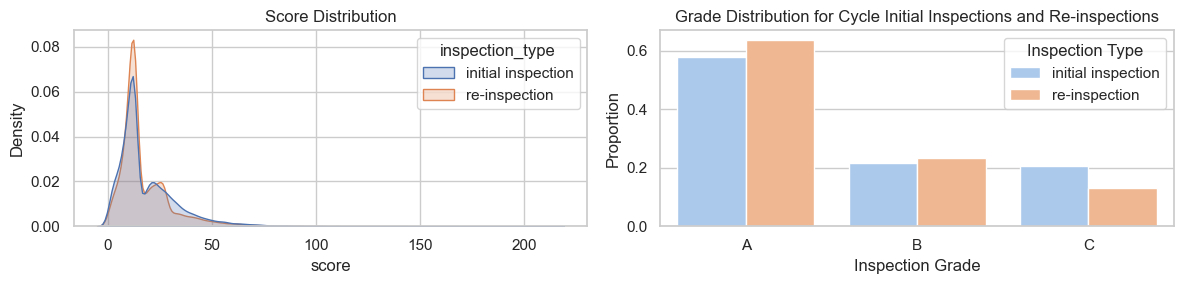

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Score distribution 
ax = axes[0]
sns.kdeplot(data=df_filtered, 
             x='score',
             hue='inspection_type',
             fill=True,
             common_norm=False,
             ax=ax)

ax.set_title('Score Distribution')

# grade distribution
ax = axes[1]
grade_dist = df_filtered.groupby('inspection_type')['grade'].value_counts(normalize=True).reset_index()

sns.barplot(
    data=grade_dist,
    x="grade",
    y="proportion",
    hue="inspection_type",
    order=['A', 'B', 'C'],
    palette="pastel",
    ax=ax,
)

ax.set_xlabel("Inspection Grade")
ax.set_ylabel("Proportion")
ax.set_title("Grade Distribution for Cycle Initial Inspections and Re-inspections")
ax.legend(title="Inspection Type")

plt.tight_layout()
plt.show()

Q: How often does a specific restaurant appear in the dataset, and what is the typical time between inspections?

In this case, we are only interested in the initial inspection window. Re-inspections occur if a B or C grade are received, presumably at some time closer than the next cyclic inspection would have occured at. For the waiting time between inspections, we are interested if the data follows the claimed policy:

>If the initial score is less than 14 points, the next initial inspection occurs approximately 12 months later; if the higher of the scores is 14-27 points, the next initial  will be 5 to 7 months after re-inspection; if the higher score is 28 or more points, the next initial inspection will occur 3 to 5 months after re-inspection.

To do so, we look at the waiting time between the last re-inspection (or initial inspection if an A was received) and the next initial inspection, and see how this varies as a function of the maximum of the last re-inspection score and the initial inspection score. A summary of our below results:

* Restaurants typically only appear a handful of times in the dataset.
* Re-inspections occur much sooner than the typical yearly inspection, coming around 110 days after the initial inspection where violations were observed.
* The data qualitatively matches the stated policy: worse inspection outcomes are followed by shorter waits until the next initial inspection. However, actual waits are longer and more dispersed than the nominal policy windows, especially for restaurants previously receiving an A.

<div align="center">

| Previous grade | Stated waiting time | Observed median wait | Observed mean wait |
|---|---:|---:|---:|
| A | Approximately 12 months | 482 days ≈ 15.8 months | 473 days ≈ 15.5 months |
| B | 5–7 months | 232 days ≈ 7.6 months | 268 days ≈ 8.8 months |
| C | 3–5 months | 158 days ≈ 5.2 months | 219 days ≈ 7.2 months |

</div>

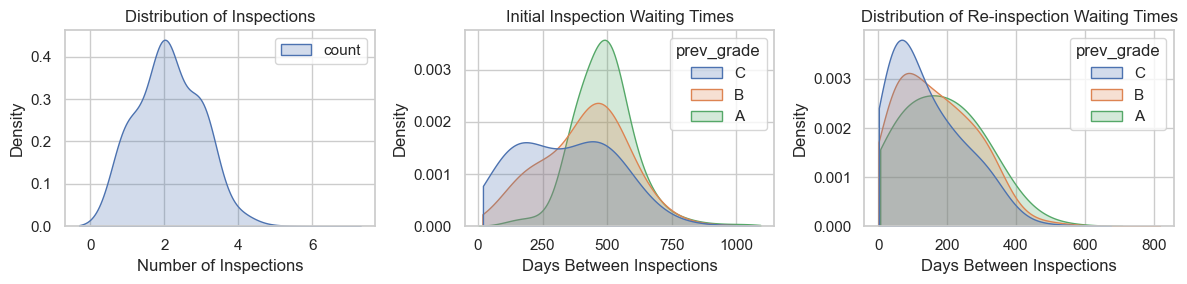

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# Distribution of inspections
rest_df = pd.DataFrame(df_filtered.query('inspection_type == "initial inspection" and inspection_program == "cycle"').groupby('id').size(), columns=['count'])

ax = axes[0]
sns.kdeplot(rest_df, fill=True, bw_adjust=4, ax=ax)
ax.set_title("Distribution of Inspections")
ax.set_xlabel("Number of Inspections")

inspection_counts_summary = pd.DataFrame(rest_df).describe()

# Waiting times between inspections
grade_to_num = {"A": 0, "B": 1, "C": 2}
num_to_grade = {0: "A", 1: "B", 2: "C"}

wait_df = df_filtered.query('inspection_program == "cycle"').copy()
wait_df.sort_values(by='date', ascending=True, inplace=True)

wait_df["wait"] = wait_df.groupby("id")["date"].diff().dt.days
wait_df["prev_grade"] = wait_df.groupby("id")["grade"].shift(1)
wait_df["prev_type"] = wait_df.groupby("id")["inspection_type"].shift(1)
wait_df["prevprev_grade"] = wait_df.groupby("id")["grade"].shift(2)

# Convert grades to numeric severity: A < B < C
wait_df["prev_grade_num"] = wait_df["prev_grade"].map(grade_to_num)
wait_df["prevprev_grade_num"] = wait_df["prevprev_grade"].map(grade_to_num)

# Calculate worse grade between initial inspection and re-inspection.
# If the previous inspection was a re-inspection, compare that grade
# to the grade immediately before it.
wait_df["prev_grade_num_adjusted"] = np.where(
    wait_df["prev_type"].eq("re-inspection"),
    wait_df[["prev_grade_num", "prevprev_grade_num"]].max(axis=1),
    wait_df["prev_grade_num"]
)

# Map back to letter grade
wait_df["prev_grade"] = wait_df["prev_grade_num_adjusted"].map(num_to_grade)

# Restrict to only initial inspections
wait_df.dropna(subset=['wait', 'grade'], inplace=True)
#wait_df = wait_df.query('inspection_type == "initial inspection"')

ax = axes[1]
sns.kdeplot(wait_df.query('inspection_type == "initial inspection"'), 
            x='wait',
            fill=True, 
            bw_adjust=3, 
            common_norm=False,
            hue='prev_grade',
            cut=0,
            clip=(0, None),
            ax=ax)

ax.set_title("Initial Inspection Waiting Times")
ax.set_xlabel("Days Between Inspections")

ax = axes[2]
sns.kdeplot(wait_df.query('inspection_type == "re-inspection"'), 
            x='wait',
            fill=True, 
            bw_adjust=3, 
            common_norm=False,
            cut=0,
            clip=(0, None),
            hue='prev_grade',
            ax=ax)

ax.set_title("Distribution of Re-inspection Waiting Times")
ax.set_xlabel("Days Between Inspections")

plt.tight_layout()

wait_summary = wait_df.groupby(['inspection_type', 'prev_grade'])['wait'].describe()

side_by_side_tables(
    [inspection_counts_summary, wait_summary],
    [
        "Inspections per restaurant",
        "Inter-inspection time by previous grade"
    ]
)